Aqui está o **Statement** formatado seguindo o padrão rigoroso do HackerRank para o problema **Even Tree** (ou **Even Forest**), baseado nas especificações e lógica discutidas nos seus planos.

---

# Even Tree

Você recebe uma árvore (um grafo conectado sem ciclos) com **$N$** nós e **$M$** arestas. Os nós são numerados de **$1$** a **$N$**. Sua tarefa é remover o número máximo de arestas da árvore de modo que cada componente conectado da "floresta" resultante contenha um número **par** de nós.

### Input Format

A primeira linha contém dois inteiros separados por espaço, **$N$** (número de nós) e **$M$** (número de arestas).
Cada uma das próximas **$M$** linhas contém dois inteiros separados por espaço, **$u$** e **$v$**, que representam uma aresta entre o nó **$u$** e o nó **$v$**.

### Constraints

*   $2 \leq N \leq 100$
*   $M = N - 1$ (A estrutura é sempre uma árvore)
*   É garantido que $N$ é um número **par** para que uma solução válida exista.

### Output Format

Imprima um único inteiro representando o número máximo de arestas que podem ser removidas para formar uma floresta onde cada árvore tenha um número par de nós.

---

### Sample Input

```text
10 9
2 1
3 1
4 3
5 2
6 1
7 2
8 6
9 8
10 8
```

### Sample Output

```text
2
```

### Explanation

Considere a árvore fornecida no exemplo:
1.  Removendo a aresta entre o nó **$1$** e o nó **$3$**, a subárvore enraizada em **$3$** conterá os nós **$\{3, 4\}$** (tamanho $2$, que é par).
2.  Removendo a aresta entre o nó **$1$** e o nó **$6$**, a subárvore enraizada em **$6$** conterá os nós **$\{6, 8, 9, 10\}$** (tamanho $4$, que é par).
3.  O componente restante conectado ao nó raiz **$1$** conterá os nós **$\{1, 2, 5, 7\}$** (tamanho $4$, que é par).

O número total de arestas removidas é **$2$**. Note que qualquer outra tentativa de remover mais arestas resultaria em pelo menos um componente com um número ímpar de nós.

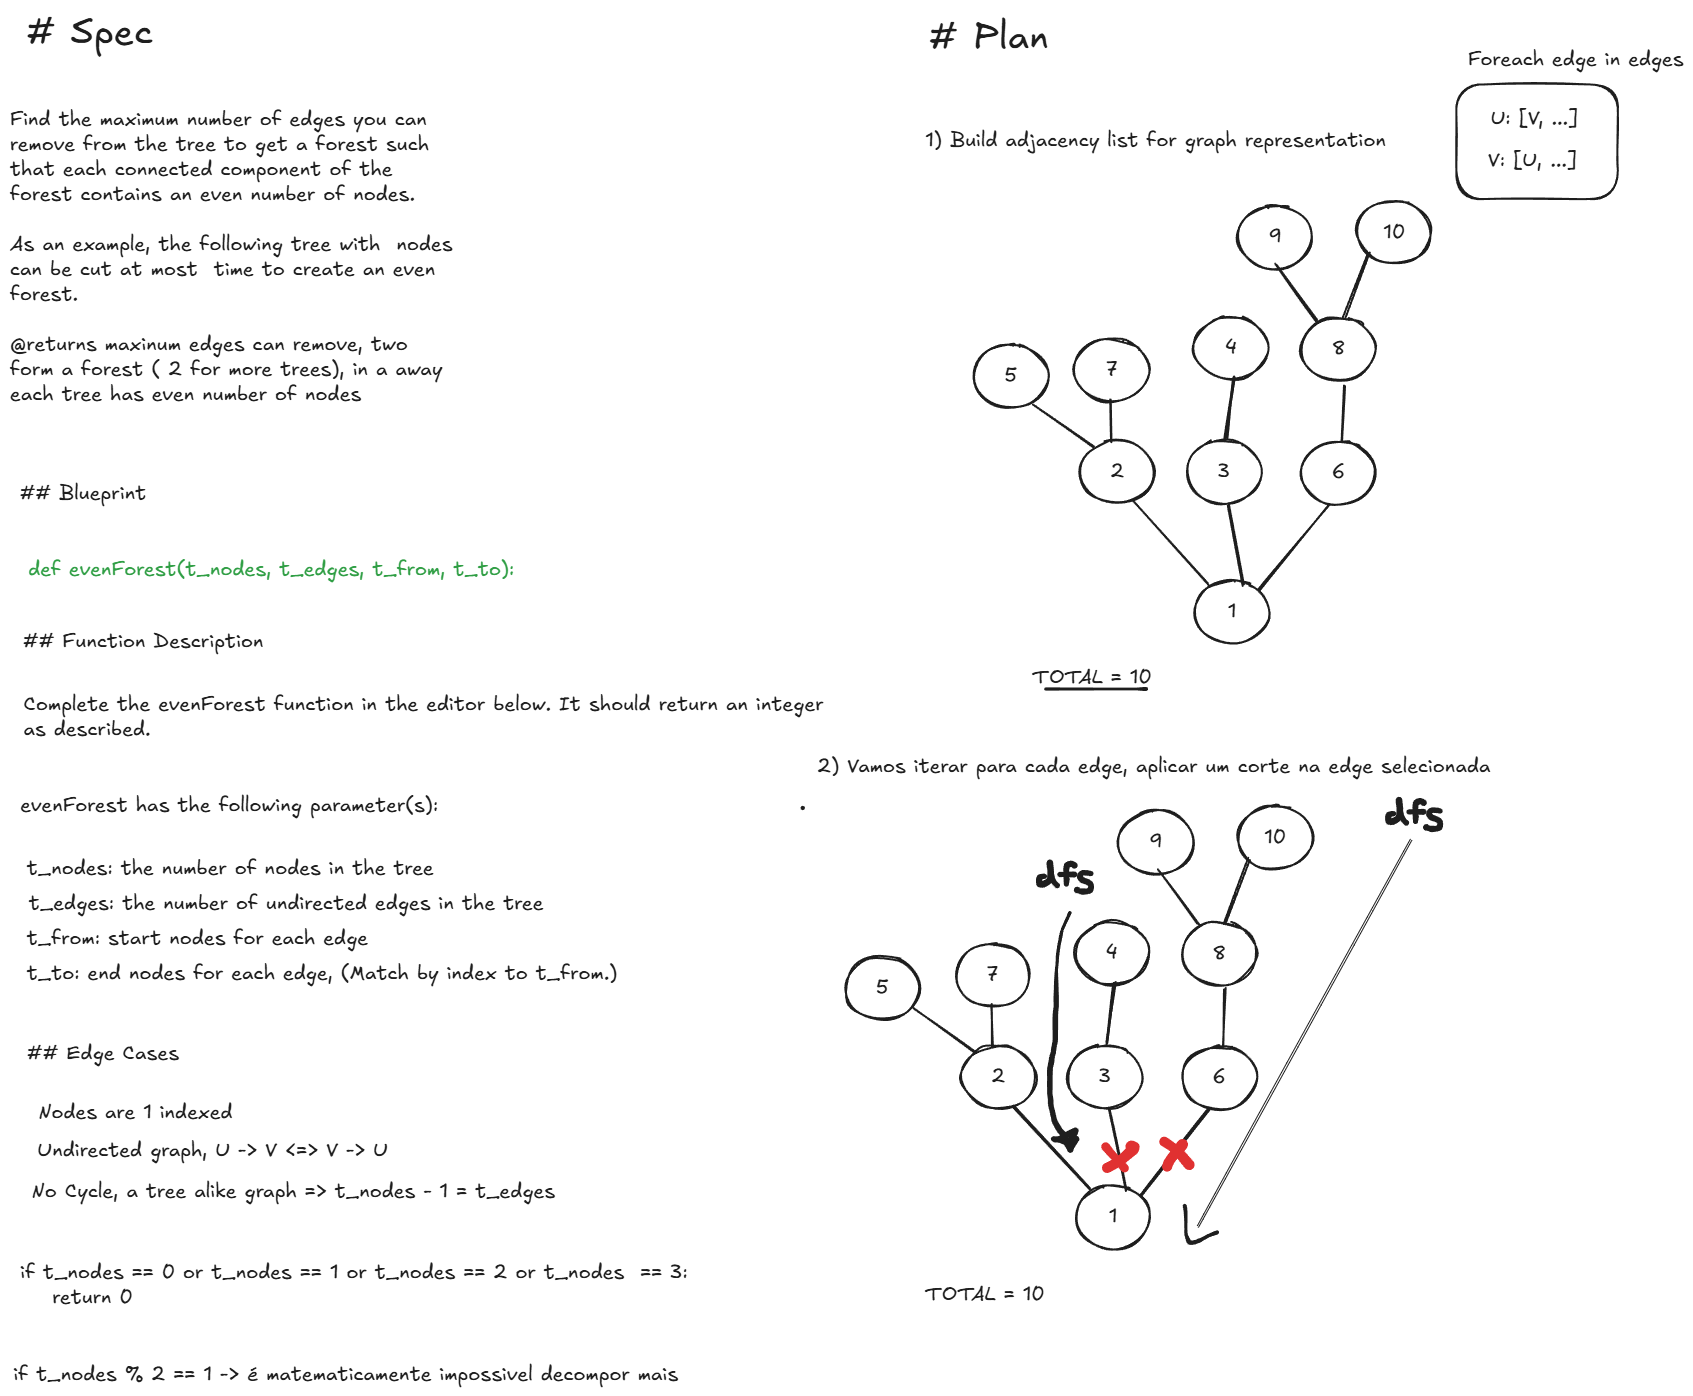

In [ ]:
#!/bin/python3

import os
import heapq
from collections import defaultdict
from typing import List


# =========================================================
# DIJKSTRA
# =========================================================

def shortestReach(
    n: int,
    edges: List[List[int]],
    s: int
) -> List[int]:

    # =====================================================
    # BUILD GRAPH
    # =====================================================

    graph = defaultdict(list)

    for u, v, w in edges:

        graph[u].append((v, w))
        graph[v].append((u, w))

    # O(E)

    # =====================================================
    # DISTANCES
    # =====================================================


    dist = [float('inf')] * (n + 1)

    dist[s] = 0

    # =====================================================
    # MIN HEAP
    # =====================================================

    min_heap = [(0, s)]

    # (distance, node)

    # =====================================================
    # DIJKSTRA
    # =====================================================

    while min_heap:

        current_dist, node = heapq.heappop(min_heap)

        # stale heap entry
        if current_dist > dist[node]:
            continue

        # -------------------------------------------------
        # EXPLORE NEIGHBORS
        # -------------------------------------------------

        for neighbor, weight in graph[node]:

            new_dist = current_dist + weight

            # relaxation
            if new_dist < dist[neighbor]:

                dist[neighbor] = new_dist

                heapq.heappush(
                    min_heap,
                    (new_dist, neighbor)
                )

        # O(E log V)

    # =====================================================
    # BUILD ANSWER
    # =====================================================

    result = []

    for node in range(1, n + 1):

        if node == s:
            continue

        if dist[node] == float('inf'):
            result.append(-1)
        else:
            result.append(dist[node])

    return result


# =========================================================
# DRIVER
# =========================================================

if __name__ == '__main__':

    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    t = int(input().strip())

    for _ in range(t):

        n, m = map(
            int,
            input().rstrip().split()
        )

        edges = []

        for _ in range(m):

            u, v, w = map(
                int,
                input().rstrip().split()
            )

            edges.append([u, v, w])

        s = int(input().strip())

        result = shortestReach(
            n,
            edges,
            s
        )

        fptr.write(' '.join(map(str, result)))
        fptr.write('\n')

    fptr.close()
